In [4]:
import torch
import torchvision.datasets as datasets

mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

len(mnist_trainset)
len(mnist_testset)



10000

In [10]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
import numpy as np

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an MLP classifier
import pandas as pd

results = []

hidden_sizes = [(10,), (50,), (100,), (200,), (300,)]
subset_sizes = [100, 500, 1000, 5000, 10000]

for subset_n in subset_sizes:
    indices = np.random.choice(len(X_train), size=subset_n, replace=False)
    X_train_subset = X_train[indices]
    y_train_subset = y_train[indices]

    for size in hidden_sizes:
        mlp = MLPClassifier(hidden_layer_sizes=size, max_iter=1000, random_state=42, verbose=False)
        mlp.fit(X_train_subset, y_train_subset)

        train_pred_probs = mlp.predict_proba(X_train_subset)
        test_pred_probs = mlp.predict_proba(X_test)

        train_loss = log_loss(y_train_subset, train_pred_probs)
        test_loss = log_loss(y_test, test_pred_probs)
        generalization_gap = test_loss - train_loss

        param_count = (784+1)*size[0] + (size[0]+1)*10

        results.append({
            "model_size": size[0],
            "params": param_count,
            "data_size": subset_n,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "gap": generalization_gap
        })

        print(f"Size: {size}, Data: {subset_n}, Params: ~{param_count}, Gap: {generalization_gap:.4f}")

# Save to CSV
df = pd.DataFrame(results)
df.to_csv("generalization_results.csv", index=False)


Size: (10,), Data: 100, Params: ~7960, Gap: 3.4635
Size: (50,), Data: 100, Params: ~39760, Gap: 12.9882
Size: (100,), Data: 100, Params: ~79510, Gap: 13.1663
Size: (200,), Data: 100, Params: ~159010, Gap: 12.6610
Size: (300,), Data: 100, Params: ~238510, Gap: 11.3933
Size: (10,), Data: 500, Params: ~7960, Gap: 0.4664
Size: (50,), Data: 500, Params: ~39760, Gap: 6.7376
Size: (100,), Data: 500, Params: ~79510, Gap: 5.9461
Size: (200,), Data: 500, Params: ~159010, Gap: 5.8182
Size: (300,), Data: 500, Params: ~238510, Gap: 5.4985
Size: (10,), Data: 1000, Params: ~7960, Gap: 1.4546
Size: (50,), Data: 1000, Params: ~39760, Gap: 5.5198
Size: (100,), Data: 1000, Params: ~79510, Gap: 4.8155
Size: (200,), Data: 1000, Params: ~159010, Gap: 4.4633
Size: (300,), Data: 1000, Params: ~238510, Gap: 4.4079
Size: (10,), Data: 5000, Params: ~7960, Gap: 0.7797
Size: (50,), Data: 5000, Params: ~39760, Gap: 2.7862
Size: (100,), Data: 5000, Params: ~79510, Gap: 2.5041
Size: (200,), Data: 5000, Params: ~15901

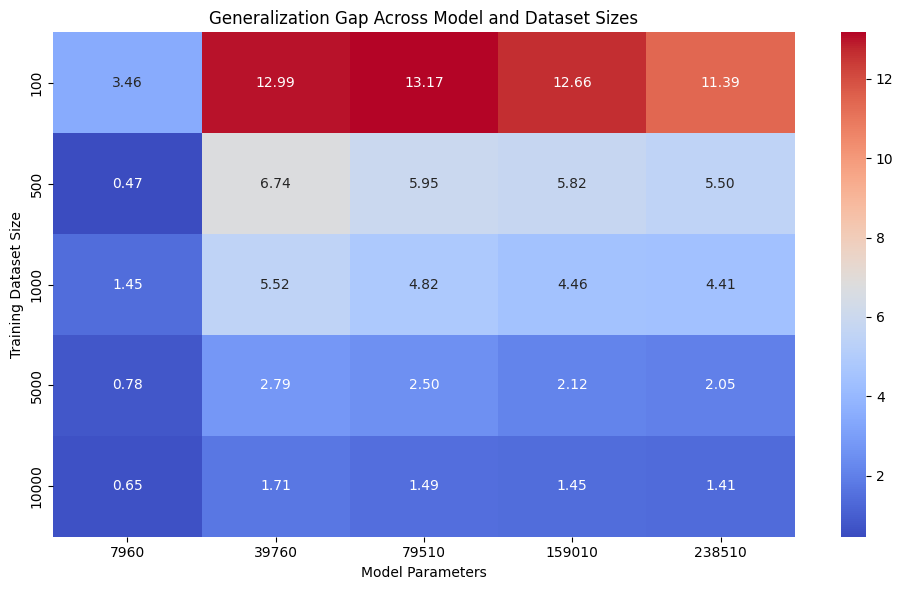

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/generalization_results.csv")

# Create pivot table for heatmap
pivot = df.pivot(index="data_size", columns="params", values="gap")

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Generalization Gap Across Model and Dataset Sizes")
plt.xlabel("Model Parameters")
plt.ylabel("Training Dataset Size")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
import numpy as np

# Fetch FashionMNIST
fashion = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X, y = fashion["data"], fashion["target"]


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an MLP classifier
import pandas as pd

results = []

hidden_sizes = [(10,), (50,), (100,), (200,), (300,)]
subset_sizes = [100, 500, 1000, 5000, 10000]

for subset_n in subset_sizes:
    indices = np.random.choice(len(X_train), size=subset_n, replace=False)
    X_train_subset = X_train[indices]
    y_train_subset = y_train[indices]

    for size in hidden_sizes:
        mlp = MLPClassifier(hidden_layer_sizes=size, max_iter=1000, random_state=42, verbose=False)
        mlp.fit(X_train_subset, y_train_subset)

        train_pred_probs = mlp.predict_proba(X_train_subset)
        test_pred_probs = mlp.predict_proba(X_test)

        train_loss = log_loss(y_train_subset, train_pred_probs)
        test_loss = log_loss(y_test, test_pred_probs)
        generalization_gap = test_loss - train_loss

        param_count = (784+1)*size[0] + (size[0]+1)*10

        results.append({
            "model_size": size[0],
            "params": param_count,
            "data_size": subset_n,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "gap": generalization_gap
        })

        print(f"Size: {size}, Data: {subset_n}, Params: ~{param_count}, Gap: {generalization_gap:.4f}")

# Save to CSV
df = pd.DataFrame(results)
df.to_csv("generalization_results_fashion_mnist.csv", index=False)



Size: (10,), Data: 100, Params: ~7960, Gap: 0.5575
Size: (50,), Data: 100, Params: ~39760, Gap: 12.2687
Size: (100,), Data: 100, Params: ~79510, Gap: 11.3126
Size: (200,), Data: 100, Params: ~159010, Gap: 12.4110
Size: (300,), Data: 100, Params: ~238510, Gap: 9.9520
Size: (10,), Data: 500, Params: ~7960, Gap: 0.3126
Size: (50,), Data: 500, Params: ~39760, Gap: 6.8383
Size: (100,), Data: 500, Params: ~79510, Gap: 6.8708
Size: (200,), Data: 500, Params: ~159010, Gap: 7.5690
Size: (300,), Data: 500, Params: ~238510, Gap: 7.0016
Size: (10,), Data: 1000, Params: ~7960, Gap: 0.2814
Size: (50,), Data: 1000, Params: ~39760, Gap: 6.4885
Size: (100,), Data: 1000, Params: ~79510, Gap: 5.9364
Size: (200,), Data: 1000, Params: ~159010, Gap: 6.0727
Size: (300,), Data: 1000, Params: ~238510, Gap: 5.6368
Size: (10,), Data: 5000, Params: ~7960, Gap: 0.1094
Size: (50,), Data: 5000, Params: ~39760, Gap: 0.9159
Size: (100,), Data: 5000, Params: ~79510, Gap: 2.2353
Size: (200,), Data: 5000, Params: ~159010

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Basic residual block
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return F.relu(out)


In [23]:
# 🏗️ Custom ResNet Model
class CustomResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10, initial_channels=64):
        super(CustomResNet, self).__init__()
        self.in_channels = initial_channels
        self.conv1 = nn.Conv2d(3, initial_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(initial_channels)

        self.layer1 = self._make_layer(block, initial_channels, layers[0])
        self.layer2 = self._make_layer(block, initial_channels * 2, layers[1], stride=2)
        self.layer3 = self._make_layer(block, initial_channels * 4, layers[2], stride=2)
        self.layer4 = self._make_layer(block, initial_channels * 8, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(initial_channels * 8, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        layers = [block(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x



In [24]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time

# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)


In [16]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, DataLoader
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

# Make sure everything is reproducible
torch.manual_seed(42)
np.random.seed(42)

# === CONFIG ===
model_configs = {
    "ResNet6": [1, 1, 1, 1],
    "ResNet10": [1, 1, 2, 2],
    "ResNet18": [2, 2, 2, 2],
    "ResNet34": [3, 4, 6, 3]
}
subset_sizes = [1000, 5000, 10000, 25000, 40000]
output_path = "data/resnet_generalization_results.csv"
os.makedirs("data", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 10
batch_size = 128

# === Data Prep ===
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# === Metric Functions ===
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)
    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)
    return total_loss / total, 100. * correct / total


In [26]:
results = []

for model_name, layer_config in model_configs.items():
    for n in subset_sizes:
        print(f"\n⏳ Training {model_name} on {n} samples...")

        indices = np.random.choice(len(train_dataset), size=n, replace=False)
        subset = Subset(train_dataset, indices)
        train_loader = DataLoader(subset, batch_size=batch_size, shuffle=True)

        model = CustomResNet(BasicBlock, layer_config).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            train_loss, train_acc = train(model, train_loader, optimizer, criterion)
            test_loss, test_acc = evaluate(model, test_loader, criterion)
            print(f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Gap: {test_loss - train_loss:.4f}")

        results.append({
            "model_name": model_name,
            "layers": str(layer_config),
            "params": count_parameters(model),
            "data_size": n,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "gap": test_loss - train_loss,
            "train_acc": train_acc,
            "test_acc": test_acc
        })

# Save results
df = pd.DataFrame(results)
df.to_csv(output_path, index=False)
print(f"\n✅ Results saved to {output_path}")



⏳ Training ResNet6 on 1000 samples...
[1/10] Train Loss: 2.2071, Test Loss: 2.3741, Gap: 0.1670
[2/10] Train Loss: 1.7096, Test Loss: 2.2716, Gap: 0.5621
[3/10] Train Loss: 1.4764, Test Loss: 2.3922, Gap: 0.9158
[4/10] Train Loss: 1.2699, Test Loss: 2.2882, Gap: 1.0183
[5/10] Train Loss: 1.0215, Test Loss: 1.9520, Gap: 0.9305
[6/10] Train Loss: 0.8219, Test Loss: 1.7218, Gap: 0.8999
[7/10] Train Loss: 0.5859, Test Loss: 1.7405, Gap: 1.1546
[8/10] Train Loss: 0.3472, Test Loss: 1.9023, Gap: 1.5551
[9/10] Train Loss: 0.1885, Test Loss: 1.9413, Gap: 1.7528
[10/10] Train Loss: 0.1078, Test Loss: 2.3558, Gap: 2.2479

⏳ Training ResNet6 on 5000 samples...
[1/10] Train Loss: 1.7691, Test Loss: 1.8098, Gap: 0.0406
[2/10] Train Loss: 1.4766, Test Loss: 1.6585, Gap: 0.1819
[3/10] Train Loss: 1.2940, Test Loss: 1.4691, Gap: 0.1752
[4/10] Train Loss: 1.1006, Test Loss: 1.5038, Gap: 0.4032
[5/10] Train Loss: 0.9773, Test Loss: 1.6021, Gap: 0.6249
[6/10] Train Loss: 0.8442, Test Loss: 1.3640, Gap: 

KeyboardInterrupt: 